In [ ]:
##By Wyatt Van Dyke
##importing stuff
!pip install CurrencyConverter
import pandas as pd
import numpy as np
from currency_converter import CurrencyConverter
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import drive
drive.mount('/content/drive')

pd.options.display.max_rows = 100  # default is 60 rows

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#I used Sublime Text to fix the file and encode it in UTF-8
file_path = '/content/drive/My Drive/wfp_market_food_prices.csv'  # Update the path if needed
df_market = pd.read_csv(file_path, encoding='ISO-8859-1')

In [ ]:
df_market.shape

(743914, 18)

In [ ]:
df_market.values

array([[1, 'Afghanistan', 272, ..., 2014, 50.0, 'WFP'],
       [1, 'Afghanistan', 272, ..., 2014, 50.0, 'WFP'],
       [1, 'Afghanistan', 272, ..., 2014, 50.0, 'WFP'],
       ...,
       [70001, 'South Sudan', 2750, ..., 2017, 95.0, 'WFP'],
       [70001, 'South Sudan', 2750, ..., 2017, 95.0, 'WFP'],
       [70001, 'South Sudan', 2750, ..., 2017, 93.7, 'WFP']], dtype=object)

In [ ]:
df_market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 743914 entries, 0 to 743913
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   adm0_id             743914 non-null  int64  
 1   adm0_name           743914 non-null  object 
 2   adm1_id             743914 non-null  int64  
 3   adm1_name           729965 non-null  object 
 4   mkt_id              743914 non-null  int64  
 5   mkt_name            743914 non-null  object 
 6   cm_id               743914 non-null  int64  
 7   cm_name             743914 non-null  object 
 8   cur_id              743914 non-null  int64  
 9   cur_name            743914 non-null  object 
 10  pt_id               743914 non-null  int64  
 11  pt_name             743914 non-null  object 
 12  um_id               743914 non-null  int64  
 13  um_name             743914 non-null  object 
 14  mp_month            743914 non-null  int64  
 15  mp_year             743914 non-nul

In [ ]:
filter_middleeast = df_market[df_market['adm0_name'].isin(['Azerbaijan', 'Jordan', 'Lebanon', 'Syrian Arab Republic', 'Turkey', 'Yemen'])].copy()

In [ ]:
filter_middleeast

,adm0_id,adm0_name,adm1_id,adm1_name,mkt_id,mkt_name,cm_id,cm_name,cur_id,cur_name,pt_id,pt_name,um_id,um_name,mp_month,mp_year,mp_price,mp_commoditysource
12538,19,Azerbaijan,0,NaN,225,National Average,58,Wheat flour,36,AZN,15,Retail,5,KG,1,2007,0.29,The State Statistical Committee of the Republi...
12539,19,Azerbaijan,0,NaN,225,National Average,58,Wheat flour,36,AZN,15,Retail,5,KG,2,2007,0.31,The State Statistical Committee of the Republi...
12540,19,Azerbaijan,0,NaN,225,National Average,58,Wheat flour,36,AZN,15,Retail,5,KG,3,2007,0.32,The State Statistical Committee of the Republi...
12541,19,Azerbaijan,0,NaN,225,National Average,58,Wheat flour,36,AZN,15,Retail,5,KG,4,2007,0.32,The State Statistical Committee of the Republi...
12542,19,Azerbaijan,0,NaN,225,National Average,58,Wheat flour,36,AZN,15,Retail,5,KG,5,2007,0.33,The State Statistical Committee of the Republi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
698827,269,Yemen,144971,$Raymah,1947,Al Jabeen,424,"Peas (yellow, split)",31,YER,15,Retail,5,KG,2,2017,350.00,WFP Monitoring
698828,269,Yemen,144971,$Raymah,1947,Al Jabeen,424,"Peas (yellow, split)",31,YER,15,Retail,5,KG,3,2017,350.00,WFP Monitoring
698829,269,Yemen,144971,$Raymah,1947,Al Jabeen,424,"Peas (yellow, split)",31,YER,15,Retail,5,KG,4,2017,300.00,WFP Monitoring
698830,269,Yemen,144971,$Raymah,1947,Al Jabeen,424,"Peas (yellow, split)",31,YER,15,Retail,5,KG,5,2017,300.00,WFP Monitoring


In [ ]:
#no duplicate rows found, that's good
duplicateRows = filter_middleeast[filter_middleeast.duplicated()]
duplicateRows

,adm0_id,adm0_name,adm1_id,adm1_name,mkt_id,mkt_name,cm_id,cm_name,cur_id,cur_name,pt_id,pt_name,um_id,um_name,mp_month,mp_year,mp_price,mp_commoditysource


In [ ]:
filter_middleeast.cur_name.unique()

array(['AZN', 'JOD', 'LBP', 'SYP', 'TRY', 'YER'], dtype=object)

In [ ]:
c = CurrencyConverter()
currencies = filter_middleeast.cur_name.unique().tolist()
currencies = dict.fromkeys(currencies, pd.NA)
for key in currencies:
   try:
      currencies[key] = c.convert(1, 'USD', key)
   except:
      pass

In [ ]:
filter_middleeast.loc[:,'amount_conv'] = filter_middleeast.apply(lambda x: x.mp_price / currencies[x.cur_name], axis=1 )

In [ ]:
filter_middleeast.um_name.unique()

array(['KG', 'L', '2 KG', '300 G', '160 G', '5 KG', '30 pcs', '5 L',
       'Head', '200 G', 'Day', '1.5 KG', '650 G', '125 G', '185 G',
       '10 KG', 'Unit', 'Packet', '12 KG', '18 KG'], dtype=object)

In [ ]:
#everything is in retail
filter_middleeast.pt_name.unique()

array(['Retail'], dtype=object)

In [ ]:
filter_middleeast.loc[:, ['mp_month', 'mp_year']]

,mp_month,mp_year
12538,1,2007
12539,2,2007
12540,3,2007
12541,4,2007
12542,5,2007
...,...,...
698827,2,2017
698828,3,2017
698829,4,2017
698830,5,2017


In [ ]:
filter_middleeast.mp_commoditysource.unique()

array(['The State Statistical Committee of the Republic of Azerbaijan',
       'MoIT', 'Ministry of Industry and Trade',
       'Department of Statistics', 'WFP and Partner NGOs',
       'WFP and NGO Partners', 'WFP and NGO Parnters', 'WFP and Partners',
       'WFP', 'Primary Data WFP CO Food aid monitors', 'WFPCO',
       'Sub Offices Field Monitors', 'Field monitors',
       'Field Monitors/Sub Offices', 'Turkish Statistical Institute',
       'WFP Sub-office', 'WFP Sub-Offices', 'WFP Monitoring'],
      dtype=object)

In [ ]:
filter_middleeast.cm_name.unique()

array(['Wheat flour', 'Potatoes', 'Sugar', 'Milk (non-pasteurized)',
       'Rice (imported)', 'Eggs', 'Meat (chicken)', 'Oil (vegetable)',
       'Garlic', 'Lentils', 'Pasta', 'Tomatoes', 'Meat (chicken, whole)',
       'Meat (beef)', 'Pulses', 'Onions', 'Apples (red)', 'Oil (olive)',
       'Oranges (big size)', 'Chickpeas', 'Bananas', 'Bulgur',
       'Cheese (picon)', 'Fish (tuna, canned)', 'Bread (pita)',
       'Beans (fava, dry)', 'Meat (lamb)', 'Cheese (white, boiled)',
       'Cucumbers', 'Spinach', 'Milk (pasteurized)', 'Beans (white)',
       'Cabbage', 'Oil (sunflower)', 'Salt', 'Cucumbers (greenhouse)',
       'Milk (powder)', 'Rice (imported, Egyptian)', 'Tomatoes (paste)',
       'Lettuce', 'Meat (beef, canned)', 'Fish (sardine, canned)', 'Rice',
       'Oil', 'Meat (beef, minced)', 'Wage (non-qualified labour)',
       'Bread (bakery)', 'Bread (shop)', 'Tea', 'Fuel (diesel)', 'Dates',
       'Salt (iodised)', 'Fuel (gas)',
       'Livestock (sheep, two-year-old male)', 

In [ ]:
#removing currency since all are now USD, please ignore error
filter_middleeast = filter_middleeast.drop(['cur_id', 'cur_name'], axis=1)

In [ ]:
#thanks to raghuveer for the rename code
filter_middleeast.rename(columns={
    'adm0_id': 'country_id',
    'adm0_name': 'country_name',
    'adm1_id': 'region_id',
    'adm1_name': 'region_name',
    'mkt_id': 'market_id',
    'cm_id': 'commodity_id',
    'pt_id': 'price_type_id',
    'um_id': 'unit_measure_id',
    'mp_month': 'price_month',
    'mp_year': 'price_year',
    'mp_price': 'price'
}, inplace=True)

In [ ]:
#Thanks for the date conversion code, Pranav!
# Create a new 'month-year' period column from 'mp_year' and 'mp_month'
filter_middleeast['month_year'] = filter_middleeast['price_year'].astype(str) + '-' + filter_middleeast['price_month'].astype(str)

# Convert 'month_year' to a Period type with monthly frequency
filter_middleeast['month_year'] = pd.to_datetime(filter_middleeast['month_year'], format='%Y-%m').dt.to_period('M')

In [ ]:
filter_middleeast.describe(include='all')

,country_id,country_name,region_id,region_name,market_id,mkt_name,commodity_id,cm_name,price_type_id,pt_name,unit_measure_id,um_name,price_month,price_year,price,mp_commoditysource,amount_conv,month_year
count,50329.000000,50329,50329.000000,47329,50329.000000,50329,50329.000000,50329,50329.0,50329,50329.000000,50329,50329.000000,50329.000000,50329.000000,50329,1566.000000,50329
unique,NaN,6,NaN,53,NaN,99,NaN,77,NaN,1,NaN,20,NaN,NaN,NaN,18,1220.000000,126
top,NaN,Syrian Arab Republic,NaN,North,NaN,National Average,NaN,Sugar,NaN,Retail,NaN,KG,NaN,NaN,NaN,Field Monitors/Sub Offices,1.264947,2016-11
freq,NaN,21310,NaN,4660,NaN,3000,NaN,2984,NaN,50329,NaN,32238,NaN,NaN,NaN,12304,12.000000,1752
mean,207.786485,NaN,5438.090763,NaN,1364.966659,NaN,213.913012,NaN,15.0,NaN,20.929762,NaN,6.361104,2015.074351,3115.622137,NaN,NaN,NaN
std,53.785936,NaN,20601.776639,NaN,522.839104,NaN,112.383734,NaN,0.0,NaN,25.511433,NaN,3.528376,1.526613,12341.297067,NaN,NaN,NaN
min,19.000000,NaN,0.000000,NaN,192.000000,NaN,52.000000,NaN,15.0,NaN,5.000000,NaN,1.000000,2007.000000,0.000000,NaN,NaN,NaN
25%,141.000000,NaN,1799.000000,NaN,1129.000000,NaN,102.000000,NaN,15.0,NaN,5.000000,NaN,3.000000,2014.000000,163.000000,NaN,NaN,NaN
50%,238.000000,NaN,2836.000000,NaN,1554.000000,NaN,238.000000,NaN,15.0,NaN,5.000000,NaN,6.000000,2015.000000,500.000000,NaN,NaN,NaN
75%,238.000000,NaN,2844.000000,NaN,1701.000000,NaN,317.000000,NaN,15.0,NaN,33.000000,NaN,10.000000,2016.000000,2000.000000,NaN,NaN,NaN


In [ ]:
# Group by Country and calculate the mean, median, and standard deviation of mp_price
country_price_summary = filter_middleeast.groupby('country_name')['price'].agg(['mean', 'median', 'std', 'count']).reset_index()
country_price_summary.columns = ['Country Name', 'Mean Price', 'Median Price', 'Std Dev Price', 'Count']
print(country_price_summary,"\n")

# Group by Region
region_price_summary = filter_middleeast.groupby('region_name')['price'].agg(['mean', 'median', 'std', 'count']).reset_index()
region_price_summary.columns = ['Region Name', 'Mean Price', 'Median Price', 'Std Dev Price', 'Count']
print(region_price_summary,"\n")

# Group by Market Name
mkt_price_summary = filter_middleeast.groupby('mkt_name')['price'].agg(['mean', 'median', 'std', 'count']).reset_index()
mkt_price_summary.columns = ['Market Name', 'Mean Price', 'Median Price', 'Std Dev Price', 'Count']
print(mkt_price_summary,"\n")

# Group by Commodity Name
cm_price_summary = filter_middleeast.groupby('cm_name')['price'].agg(['mean', 'median', 'std', 'count']).reset_index()
cm_price_summary.columns = ['Commodity Name', 'Mean Price', 'Median Price', 'Std Dev Price', 'Count']
print(cm_price_summary,"\n")

# Group by Market Type (there's only one, it's retail)
mk_type_price_summary = filter_middleeast.groupby('pt_name')['price'].agg(['mean', 'median', 'std', 'count']).reset_index()
mk_type_price_summary.columns = ['Market Type', 'Mean Price', 'Median Price', 'Std Dev Price', 'Count']
print(mk_type_price_summary,"\n")

           Country Name   Mean Price  Median Price  Std Dev Price  Count
0            Azerbaijan     0.527840         0.490       0.174451    125
1                Jordan     9.016329         1.257     209.192908   2281
2               Lebanon  4092.967431      2250.000    3809.764924  15942
3  Syrian Arab Republic  3641.155709       300.000   18171.479364  21310
4                Turkey    11.857089         5.405      14.861137   1566
5                 Yemen  1529.251091       250.000    5884.401922   9105 

          Region Name   Mean Price  Median Price  Std Dev Price  Count
0   $Amanat Al Asimah   870.583822     220.00000    4197.717078    852
1             $Raymah  2062.113636     314.00000    5738.490625    220
2               Abyan  2096.545455     300.00000    6290.938226    220
3                Aden   995.674809     228.00000    4337.826776   1177
4              Ajloon     2.116512       1.22900       2.466785     82
5            Al Bayda  2696.218182     302.00000    7594.9408

In [ ]:
# Maximum Median Price by Country
max_country_index = country_price_summary['Median Price'].idxmax()
max_median_price_country = country_price_summary.loc[max_country_index]
print("Maximum Median Price by Country:", max_median_price_country['Country Name'], "with a price of:", max_median_price_country['Median Price'])

# Maximum Median Price by Locality Name
max_region_index = region_price_summary['Median Price'].idxmax()
max_median_price_region = region_price_summary.loc[max_region_index]
print("Maximum Median Price by Region Name:", max_median_price_region['Region Name'], "with a price of:", max_median_price_region['Median Price'])

# Maximum Median Price by Market Name
max_market_index = mkt_price_summary['Median Price'].idxmax()
max_median_price_market = mkt_price_summary.loc[max_market_index]
print("Maximum Median Price by Market Name:", max_median_price_market['Market Name'], "with a price of:", max_median_price_market['Median Price'])

# Maximum Median Price by Commodity Name
max_commodity_index = cm_price_summary['Median Price'].idxmax()
max_median_price_commodity = cm_price_summary.loc[max_commodity_index]
print("Maximum Median Price by Commodity Name:", max_median_price_commodity['Commodity Name'], "with a price of:", max_median_price_commodity['Median Price'])

# Maximum Median Price by Market Type Name
max_market_type_index = mk_type_price_summary['Median Price'].idxmax()
max_median_price_market_type = mk_type_price_summary.loc[max_market_type_index]
print("Maximum Median Price by Market Type:", max_median_price_market_type['Market Type'], "with a price of:", max_median_price_market_type['Median Price'])

Maximum Median Price by Country: Lebanon with a price of: 2250.0
Maximum Median Price by Region Name: Beirut with a price of: 2588.04165
Maximum Median Price by Market Name: Baabda with a price of: 2624.4898
Maximum Median Price by Commodity Name: Livestock (sheep, two-year-old male) with a price of: 60000.0
Maximum Median Price by Market Type: Retail with a price of: 500.0


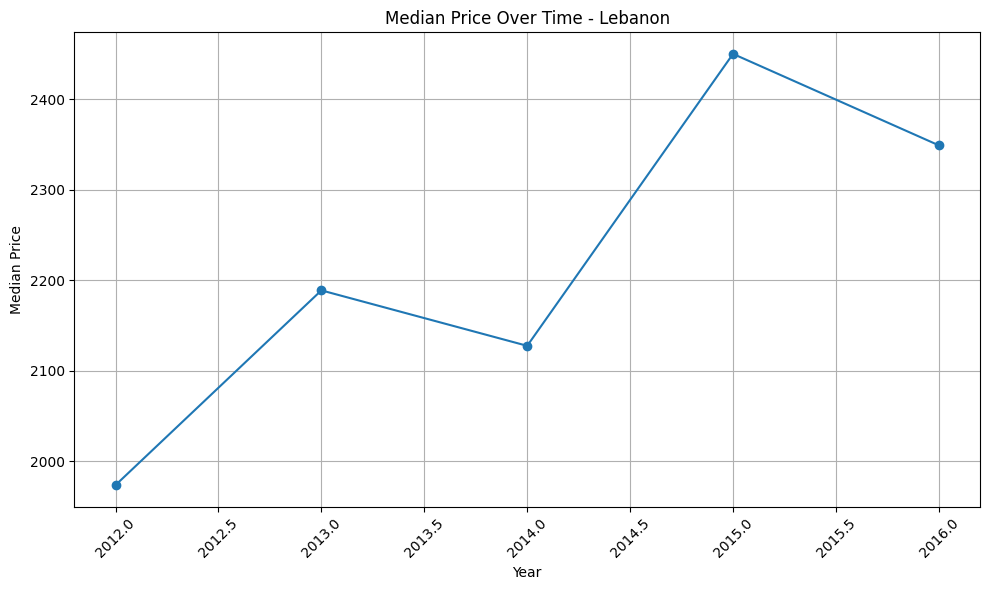

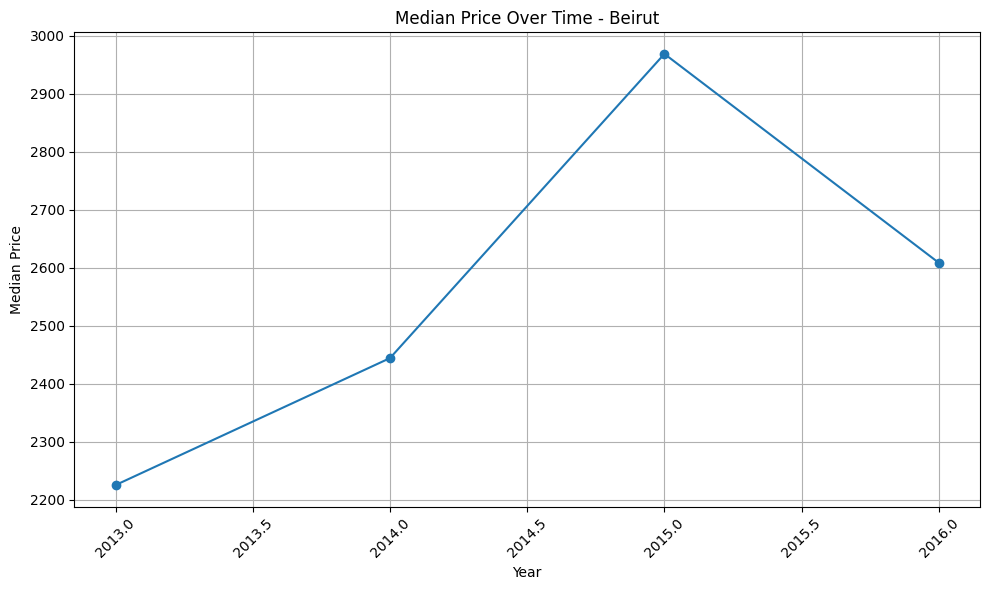

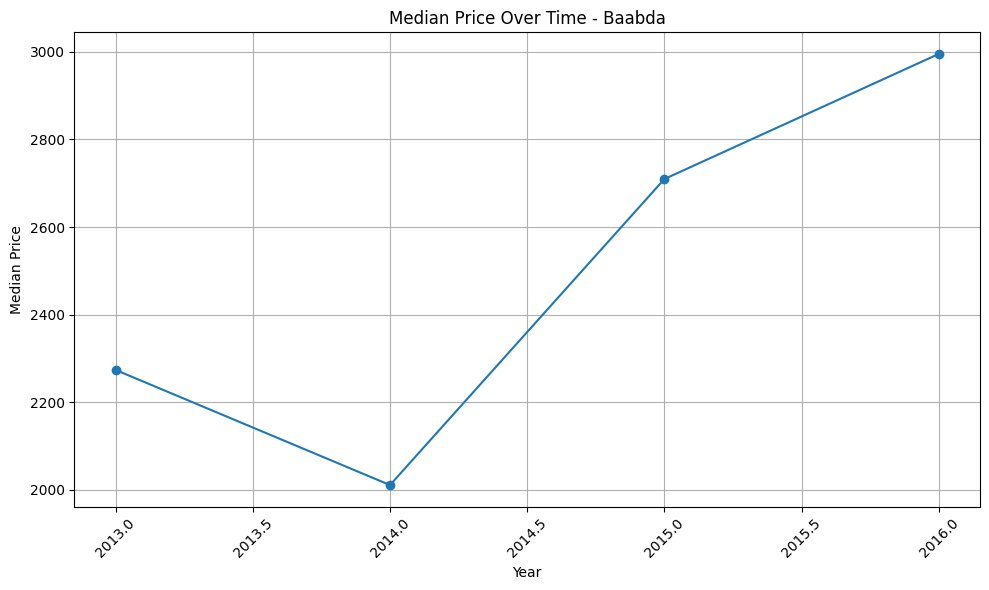

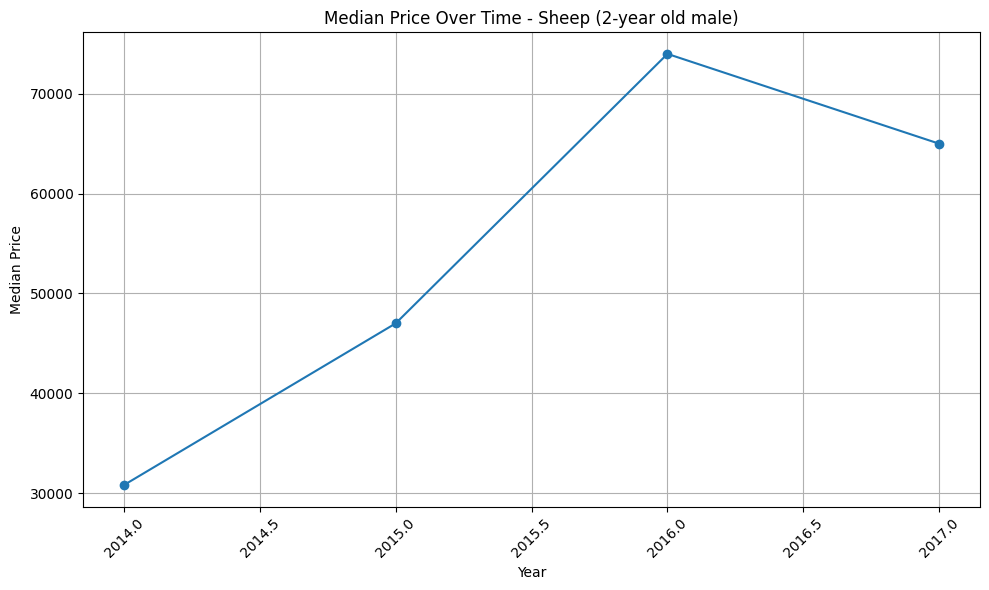

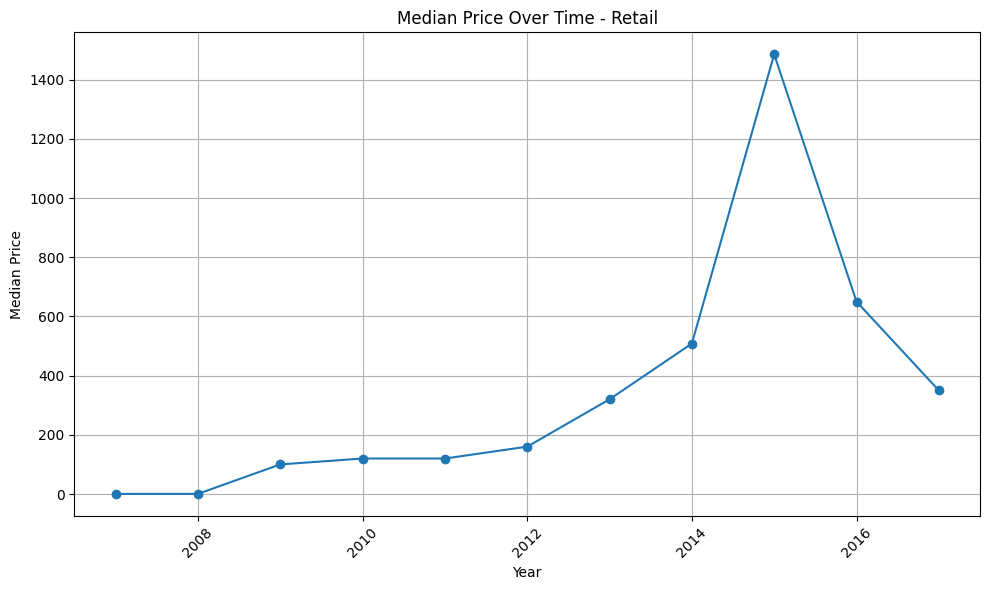

In [ ]:
# Create a function to plot median prices for a given filter and title
def plot_median_price(data, title):
    median_data = data.groupby('price_year')['price'].median().reset_index()

    plt.figure(figsize=(10, 6))
    plt.plot(median_data['price_year'], median_data['price'], marker='o', linestyle='-')
    plt.title(title)
    plt.xlabel('Year')
    plt.ylabel('Median Price')
    plt.xticks(rotation=45)
    plt.grid()
    plt.tight_layout()
    plt.show()

# Filter and plot for Lebanon
lebanon_data = filter_middleeast[filter_middleeast['country_name'] == 'Lebanon']
plot_median_price(lebanon_data, 'Median Price Over Time - Lebanon')

# Filter and plot for Beirut
beirut_data = filter_middleeast[filter_middleeast['region_name'] == 'Beirut']
plot_median_price(beirut_data, 'Median Price Over Time - Beirut')

# Filter and plot for Baabda
baabda_data = filter_middleeast[filter_middleeast['mkt_name'] == 'Baabda']
plot_median_price(baabda_data, 'Median Price Over Time - Baabda')

# Filter and plot for Sheep (2-year old male)
sheep_data = filter_middleeast[filter_middleeast['cm_name'] == 'Livestock (sheep, two-year-old male)']
plot_median_price(sheep_data, 'Median Price Over Time - Sheep (2-year old male)')

# Filter and plot for Retail
retail_data = filter_middleeast[filter_middleeast['pt_name'] == 'Retail']
plot_median_price(retail_data, 'Median Price Over Time - Retail')

In [ ]:
filter_middleeast

,country_id,country_name,region_id,region_name,market_id,mkt_name,commodity_id,cm_name,price_type_id,pt_name,unit_measure_id,um_name,price_month,price_year,price,mp_commoditysource,amount_conv,month_year
12538,19,Azerbaijan,0,NaN,225,National Average,58,Wheat flour,15,Retail,5,KG,1,2007,0.29,The State Statistical Committee of the Republi...,<NA>,2007-01
12539,19,Azerbaijan,0,NaN,225,National Average,58,Wheat flour,15,Retail,5,KG,2,2007,0.31,The State Statistical Committee of the Republi...,<NA>,2007-02
12540,19,Azerbaijan,0,NaN,225,National Average,58,Wheat flour,15,Retail,5,KG,3,2007,0.32,The State Statistical Committee of the Republi...,<NA>,2007-03
12541,19,Azerbaijan,0,NaN,225,National Average,58,Wheat flour,15,Retail,5,KG,4,2007,0.32,The State Statistical Committee of the Republi...,<NA>,2007-04
12542,19,Azerbaijan,0,NaN,225,National Average,58,Wheat flour,15,Retail,5,KG,5,2007,0.33,The State Statistical Committee of the Republi...,<NA>,2007-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
698827,269,Yemen,144971,$Raymah,1947,Al Jabeen,424,"Peas (yellow, split)",15,Retail,5,KG,2,2017,350.00,WFP Monitoring,<NA>,2017-02
698828,269,Yemen,144971,$Raymah,1947,Al Jabeen,424,"Peas (yellow, split)",15,Retail,5,KG,3,2017,350.00,WFP Monitoring,<NA>,2017-03
698829,269,Yemen,144971,$Raymah,1947,Al Jabeen,424,"Peas (yellow, split)",15,Retail,5,KG,4,2017,300.00,WFP Monitoring,<NA>,2017-04
698830,269,Yemen,144971,$Raymah,1947,Al Jabeen,424,"Peas (yellow, split)",15,Retail,5,KG,5,2017,300.00,WFP Monitoring,<NA>,2017-05


In [ ]:
me_numeric = filter_middleeast[["country_id", "region_id", "market_id", "commodity_id", "unit_measure_id", "price_month", "price_year", "price"]]

In [ ]:
me_numeric.corr()

,country_id,region_id,market_id,commodity_id,unit_measure_id,price_month,price_year,price
country_id,1.000000,0.196815,-0.418660,-0.089684,-0.003836,-0.036851,0.178851,-0.034783
region_id,0.196815,1.000000,-0.236400,-0.076171,-0.045830,0.006493,-0.033893,-0.023306
market_id,-0.418660,-0.236400,1.000000,0.158923,0.116878,-0.015228,0.281792,0.066312
commodity_id,-0.089684,-0.076171,0.158923,1.000000,0.338677,-0.023334,0.158988,0.169650
unit_measure_id,-0.003836,-0.045830,0.116878,0.338677,1.000000,-0.006811,0.069087,0.101529
price_month,-0.036851,0.006493,-0.015228,-0.023334,-0.006811,1.000000,-0.252873,0.009008
price_year,0.178851,-0.033893,0.281792,0.158988,0.069087,-0.252873,1.000000,0.058750
price,-0.034783,-0.023306,0.066312,0.169650,0.101529,0.009008,0.058750,1.000000


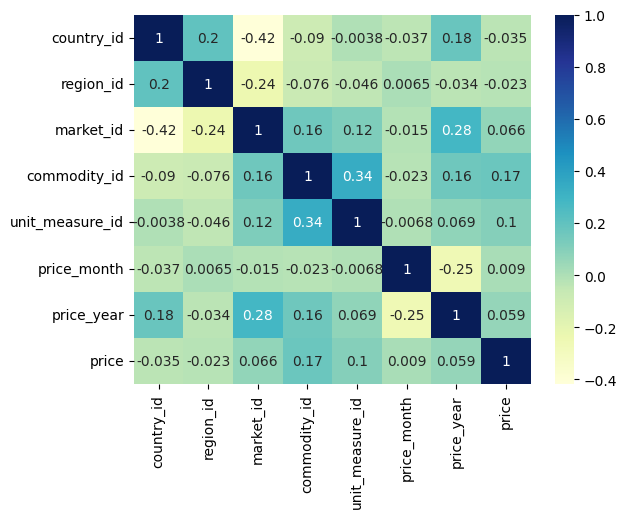

In [ ]:
dataplot = sns.heatmap(me_numeric.corr(numeric_only=True), cmap="YlGnBu", annot=True)
plt.show()

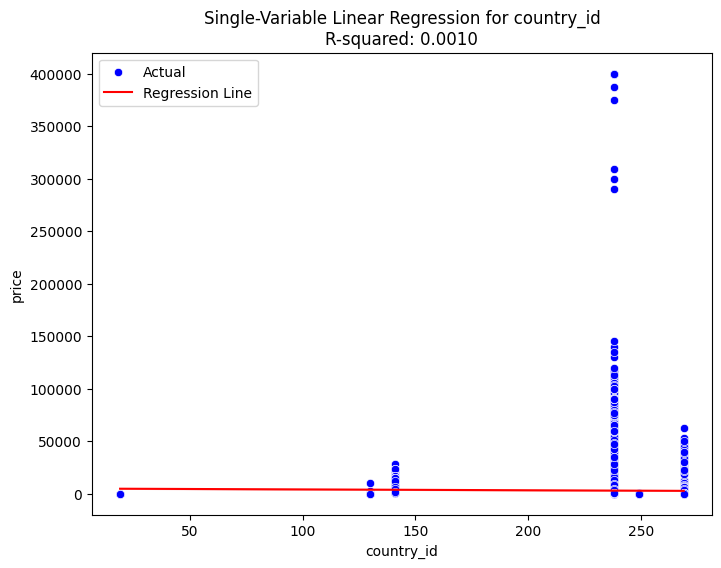

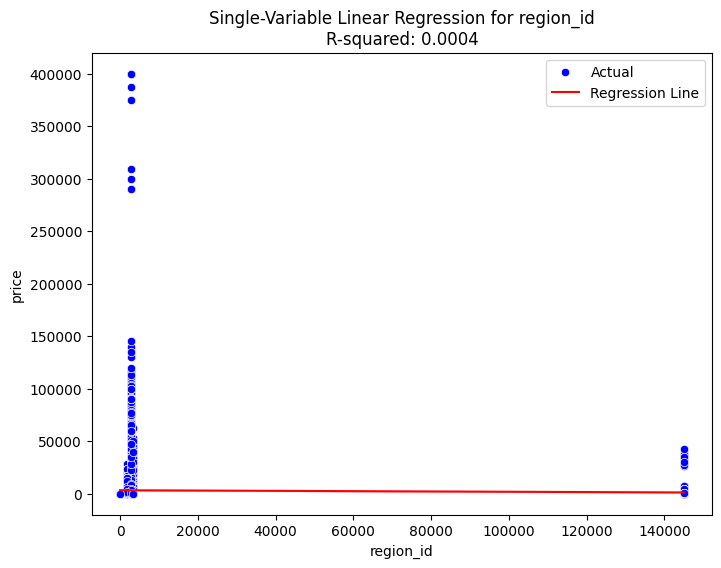

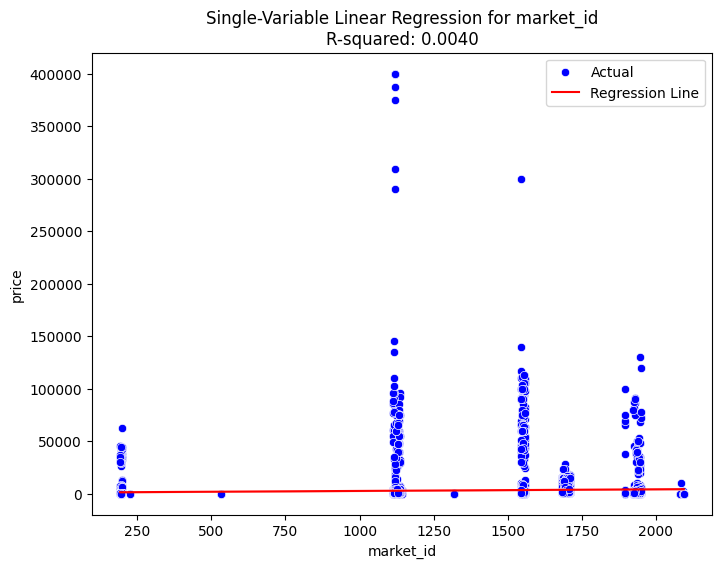

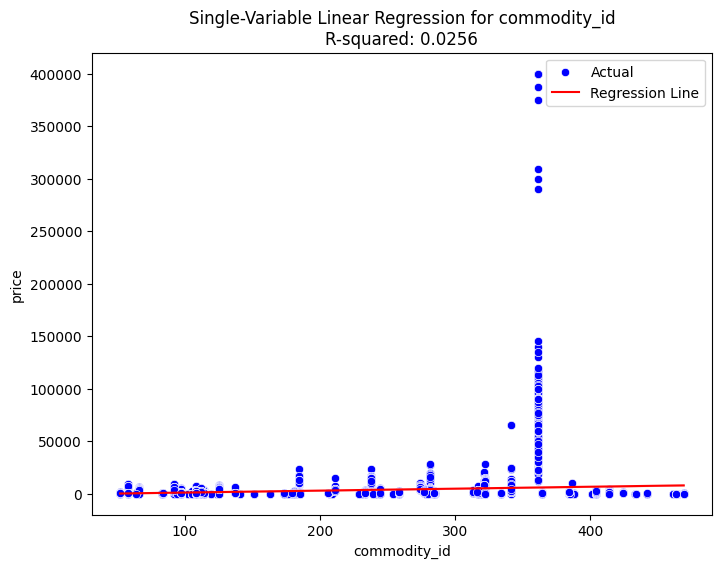

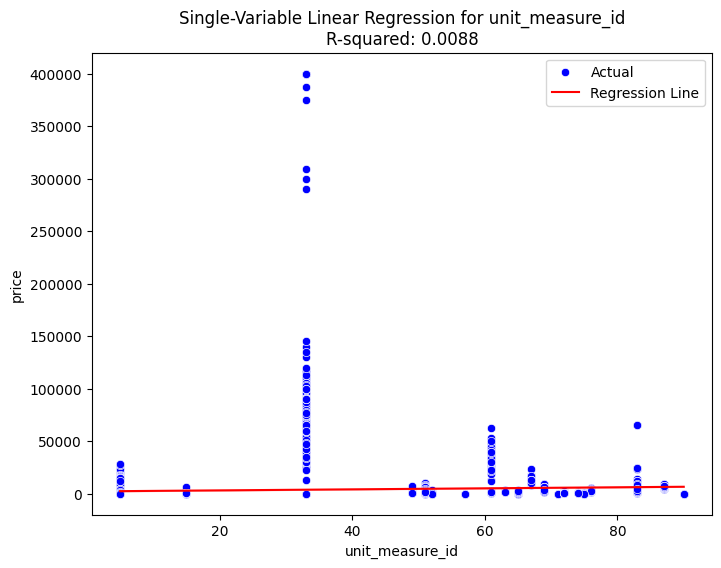

In [ ]:
#thanks pranav
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# List of individual features to test against 'price'
features = ["country_id", "region_id", "market_id", "commodity_id", "unit_measure_id"]

# Initialize the LinearRegression model
model = LinearRegression()

# Loop through each feature
for feature in features:
    X_single = me_numeric[[feature]]  # Select a single feature (reshape to 2D)
    y = me_numeric['price']  # Target variable

    # Split the data for training and testing (70% training, 30% testing)
    X_train, X_test, y_train, y_test = train_test_split(X_single, y, test_size=0.3, random_state=42)

    # Fit the linear regression model for the current feature
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Calculate the R-squared value
    r2 = r2_score(y_test, y_pred)

    # Plot the actual vs predicted values
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_test[feature], y=y_test, label='Actual', color='blue')
    sns.lineplot(x=X_test[feature], y=y_pred, label='Regression Line', color='red')

    # Add title and labels
    plt.title(f'Single-Variable Linear Regression for {feature}\nR-squared: {r2:.4f}')
    plt.xlabel(feature)
    plt.ylabel('price')

    # Show plot
    plt.legend()
    plt.show()

Not a very effective measure since we're using categorical variables in place of numeric variables, like Pranav said. Oopsie.

In [ ]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

def perform_tests(filter_middleeast, categorical_var):
    # Perform Shapiro-Wilk test for normality
    shapiro_test = stats.shapiro(filter_middleeast['price'])
    print(f"Shapiro-Wilk Test for {categorical_var}: Statistic={shapiro_test.statistic}, p-value={shapiro_test.pvalue}")

    # Check if p-value is less than significance level (e.g., 0.05)
    if shapiro_test.pvalue < 0.05:
        print(f"Normality does not hold for {categorical_var}. Proceeding with Kruskal-Wallis test.")

        # Perform Kruskal-Wallis test
        kruskal_test = stats.kruskal(*(filter_middleeast[filter_middleeast[categorical_var] == cat]['price']
                                        for cat in filter_middleeast[categorical_var].unique()))
        print(f"Kruskal-Wallis Test for {categorical_var}: Statistic={kruskal_test.statistic}, p-value={kruskal_test.pvalue}")
    else:
        print(f"Normality holds for {categorical_var}. Proceeding with ANOVA.")

        # Perform ANOVA
        model = ols(f'mp_price ~ C({categorical_var})', data=filter_middleeast).fit()
        anova_results = sm.stats.anova_lm(model, typ=2)
        print(anova_results)

categorical_vars = ['country_name', 'region_name', 'mkt_name', 'cm_name', 'price_year', 'price_month']

for var in categorical_vars:
    perform_tests(filter_middleeast, var)

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 50329.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro-Wilk Test for country_name: Statistic=0.20663272995551552, p-value=1.8570403100201624e-156
Normality does not hold for country_name. Proceeding with Kruskal-Wallis test.
Kruskal-Wallis Test for country_name: Statistic=26557.105487695888, p-value=0.0
Shapiro-Wilk Test for region_name: Statistic=0.20663272995551552, p-value=1.8570403100201624e-156
Normality does not hold for region_name. Proceeding with Kruskal-Wallis test.
Kruskal-Wallis Test for region_name: Statistic=nan, p-value=nan
Shapiro-Wilk Test for mkt_name: Statistic=0.20663272995551552, p-value=1.8570403100201624e-156
Normality does not hold for mkt_name. Proceeding with Kruskal-Wallis test.
Kruskal-Wallis Test for mkt_name: Statistic=27455.772097228557, p-value=0.0
Shapiro-Wilk Test for cm_name: Statistic=0.20663272995551552, p-value=1.8570403100201624e-156
Normality does not hold for cm_name. Proceeding with Kruskal-Wallis test.
Kruskal-Wallis Test for cm_name: Statistic=30478.55979047684, p-value=0.0
Shapiro-Wilk T

pt_name was throwing up errors so i excluded it

Kruskal-Wallis tests for country_name, mkt_name, cm_name, and price_year show very large statistics that indicate a large impact on price.

NaN result in Kruskal-Wallis test probably means we need to check the variable's data.

price_month doesn't have as big as an impact as the other variables because of its small statistic.


it crashes on that stupid polyreg.fit() function i'm gonna kms

In [ ]:
import pandas as pd

# Selecting the relevant columns
significant_vars = ['country_name', 'mkt_name', 'cm_name', 'price_year']
X = filter_middleeast[significant_vars]
y = filter_middleeast['price']

# One-hot encoding the categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)  # drop_first to avoid dummy variable trap


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

# Create polynomial features
degree = 2  # You can adjust the degree
polyreg = make_pipeline(PolynomialFeatures(degree), LinearRegression())

# Fit the model
polyreg.fit(X_train, y_train)

# Predictions and evaluation
y_pred_poly = polyreg.predict(X_test)
print(f'Polynomial Regression R^2 Score: {polyreg.score(X_test, y_test)}')


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Fit a Decision Tree Regressor
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred_tree = tree_model.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)
print(f'Mean Squared Error (Decision Tree): {mse_tree}')


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Fit a Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f'Mean Squared Error (Random Forest): {mse_rf}')


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Fit a Gradient Boosting Regressor
gbm_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbm_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred_gbm = gbm_model.predict(X_test)
mse_gbm = mean_squared_error(y_test, y_pred_gbm)
print(f'Mean Squared Error (Gradient Boosting): {mse_gbm}')


In [ ]:
from sklearn.svm import SVR

# Fit a Support Vector Regressor
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred_svr = svr_model.predict(X_test)
mse_svr = mean_squared_error(y_test, y_pred_svr)
print(f'Mean Squared Error (SVR): {mse_svr}')


In [ ]:
from sklearn.neural_network import MLPRegressor

# Fit a Multi-layer Perceptron Regressor
mlp_model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred_mlp = mlp_model.predict(X_test)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
print(f'Mean Squared Error (MLP): {mse_mlp}')
